Лабораторная работа №1 (Определение альфа-ритмов)

Касьяненко Вера и Кремпольская Екатерина

P3420


Импорт необходимых библиотек:

In [1]:
import os
from dataclasses import dataclass
from typing import Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch, hilbert, iirnotch, detrend

## Загрузка наших изменений
1. Закрытые глаза
2. Закрытые глаза и спокойная музыка
3. Закрытые глаза и рок-музыка или бодрый рэп
4. Закрытые глаза и попытки писать осознанный текст на бумаге

In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=12RRX6jTWReZs_VbVhfXbUfubLcOzFH4m' -O v1_1_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1GttByT70AtmgL8blpGuIchPKJISrlSKL' -O v2_1_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1Q1yGMjP0fbZoJOnVMLJsZVrgvBjVdkbv' -O v3_1_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1wYs6skMkjErxdSiy4N02gY0DqX_V_ePv' -O v4_1_A0_fixed.csv

In [ ]:
CONDITIONS: Dict[str, str] = {
    "Закрытые глаза (покой)": "v1_1_A0_fixed.csv",
    "Закрытые глаза + спокойная музыка": "v2_1_A0_fixed.csv",
    "Закрытые глаза + рок/рэп": "v3_1_A0_fixed.csv",
    "Закрытые глаза + письмо": "v4_1_A0_fixed.csv",
}

## Загрузка сигнала и оценка частоты дискретизации

- читаем time и amplitude;
- убираем пустые значения;
- сортируем по времени и удаляем повторы;
- сдвигаем время так, чтобы начиналось с нуля;
- оцениваем частоту дискретизации по шагу времени


In [ ]:
# Загрузка и оценка fs
@dataclass
class EEGSeries:
    t: np.ndarray
    x: np.ndarray
    fs: float

def load_csv_eeg(path: str, t_col: str = "time", x_col: str = "amplitude") -> EEGSeries:
    df = pd.read_csv(path, usecols=[t_col, x_col]).dropna()

    # Убираем дубликаты по времени и сортируем
    df = df.drop_duplicates(subset=t_col, keep="first").sort_values(t_col)

    t = df[t_col].astype(float).to_numpy()
    x = df[x_col].astype(float).to_numpy()

    # Пусть время начинается с 0
    t = t - t[0]

    # Оцениваем fs
    dt = np.diff(t)
    dt = dt[dt > 0]

    fs = float(1.0 / np.median(dt))
    return EEGSeries(t=t, x=x, fs=fs)


## Предобработка

1. Убираем постоянное смещение
2. Оставляем только частоты 1-35 Hz
3. Если возможно, вырезаем помеху на 50 Hz


In [ ]:
# Фильтрация
def preprocess(
    x: np.ndarray,
    fs: float,
    band: Tuple[float, float] = (1.0, 35.0),
    notch_hz: Optional[float] = 50.0,
    q: float = 30.0,
) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    # Убираем постоянное смещение
    x = detrend(x, type="constant")

    nyq = 0.5 * fs
    lo, hi = band

    hi = min(hi, nyq * 0.99)

    # Полосовой фильтр 1-35 Hz
    b, a = butter(4, [lo / nyq, hi / nyq], btype="band")
    y = filtfilt(b, a, x)

    # Notch 50 Hz
    if notch_hz is not None and notch_hz < nyq * 0.99:
        w0 = notch_hz / nyq
        bn, an = iirnotch(w0, q)
        y = filtfilt(bn, an, y)

    return y


## Альфа-метрики через спектр (PSD)

- строим спектр мощности (Welch);
- считаем мощность в альфа-диапазоне (8-13 Hz);
- считаем мощность в диапазоне 1-40 Hz;
- считаем относительную альфу как "долю" альфы от общего


In [ ]:
# PSD + альфа-мощность
def alpha_power_from_psd(
    x: np.ndarray,
    fs: float,
    alpha_band: Tuple[float, float] = (8.0, 13.0),
    total_band: Tuple[float, float] = (1.0, 40.0),
    nperseg: int = 1024,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    x = np.asarray(x, dtype=float)

    nperseg = int(min(nperseg, len(x)))

    f, pxx = welch(x, fs=fs, nperseg=nperseg)

    a0, a1 = alpha_band
    t0, t1 = total_band

    am = (f >= a0) & (f <= a1)
    tm = (f >= t0) & (f <= min(t1, f.max()))

    # Площадь под PSD в нужных диапазонах
    p_alpha = float(np.trapezoid(pxx[am], f[am])) if np.any(am) else 0.0
    p_total = float(np.trapezoid(pxx[tm], f[tm])) if np.any(tm) else 0.0

    rel = float(p_alpha / p_total) if p_total > 0 else 0.0
    return f, pxx, p_alpha, rel


## Альфа-составляющая и ее огибающая

- выделяем из сигнала только альфа-диапазон (8-13 Hz);
- строим "огибающую" (кривая, которая показывает, как меняется сила альфы со временем)

In [ ]:
# Альфа-компонента + огибающая
def alpha_envelope(
    x: np.ndarray,
    fs: float,
    alpha_band: Tuple[float, float] = (8.0, 13.0),
) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)

    nyq = 0.5 * fs
    lo, hi = alpha_band
    hi = min(hi, nyq * 0.99)

    # Фильтруем только альфа-диапазон
    b, a = butter(4, [lo / nyq, hi / nyq], btype="band")
    xa = filtfilt(b, a, x)

    # Огибающая через Гильберта
    env = np.abs(hilbert(xa))
    return xa, env


## Анализ одного файла и запуск по всем условиям

Для каждого условия:
- загружаем сигнал;
- фильтруем;
- считаем PSD и метрики альфы;
- выделяем альфа-сигнал и огибающую


In [ ]:
# Анализ одного условия + общий запуск
def analyze_file(path: str) -> Dict[str, Any]:
    s = load_csv_eeg(path)

    # Основная предобработка
    xf = preprocess(s.x, s.fs, band=(1, 35), notch_hz=50.0)

    # Метрики по PSD
    f, pxx, p_alpha, rel = alpha_power_from_psd(xf, s.fs)

    # Альфа по времени
    xa, env = alpha_envelope(xf, s.fs)

    return {
        "t": s.t,
        "raw": s.x,
        "filt": xf,
        "fs": s.fs,
        "freqs": f,
        "psd": pxx,
        "alpha_power": p_alpha,
        "alpha_rel": rel,
        "alpha_sig": xa,
        "alpha_env": env,
    }

def run_pipeline(conds: Dict[str, str]) -> Dict[str, Dict[str, Any]]:
    out: Dict[str, Dict[str, Any]] = {}
    for title, fp in conds.items():
        r = analyze_file(fp)
        out[title] = r
        print(f"{title}: alpha={r['alpha_power']:.6g} | rel={r['alpha_rel']:.4f} | fs={r['fs']:.2f} Hz")
    return out

results = run_pipeline(CONDITIONS)


Закрытые глаза (покой): alpha=0.133628 | rel=0.5352 | fs=81.61 Hz
Закрытые глаза + спокойная музыка: alpha=0.266723 | rel=0.4903 | fs=81.61 Hz
Закрытые глаза + рок/рэп: alpha=0.323036 | rel=0.5020 | fs=81.61 Hz
Закрытые глаза + письмо: alpha=0.171007 | rel=0.4678 | fs=81.61 Hz


## Графики для каждого условия

Для каждого условия рисуем:
- исходный и отфильтрованный сигнал;
- спектр мощности (PSD) с выделением альфа-диапазона;
- альфа-составляющую;
- огибающую альфы.

Так будет видно насколько фильтрация "успокоила" сигнал, есть ли пик в альфа-диапазоне и насколько стабильна альфа во времени


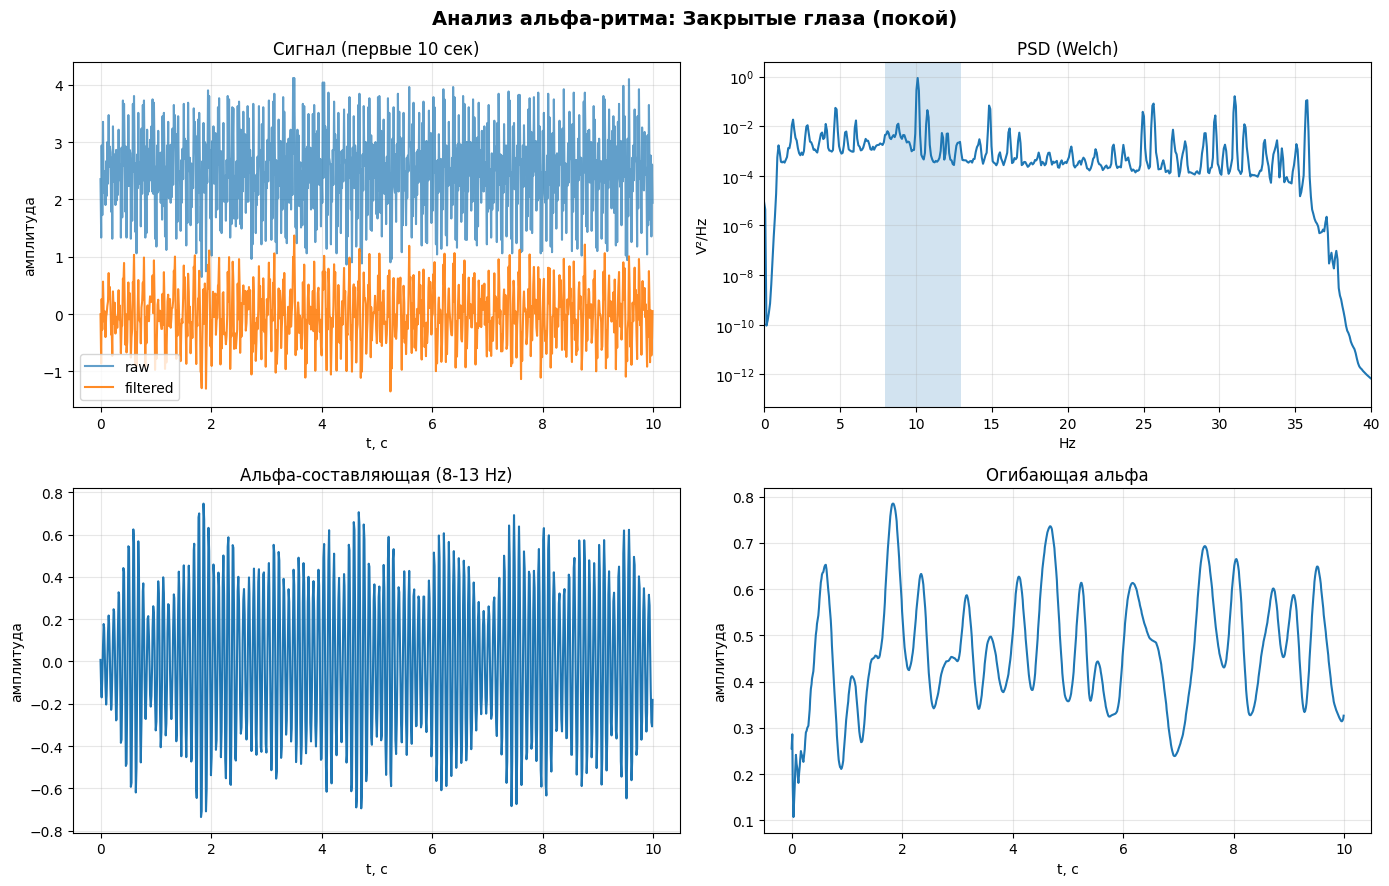

Закрытые глаза (покой): alpha=0.133628, rel=0.5352


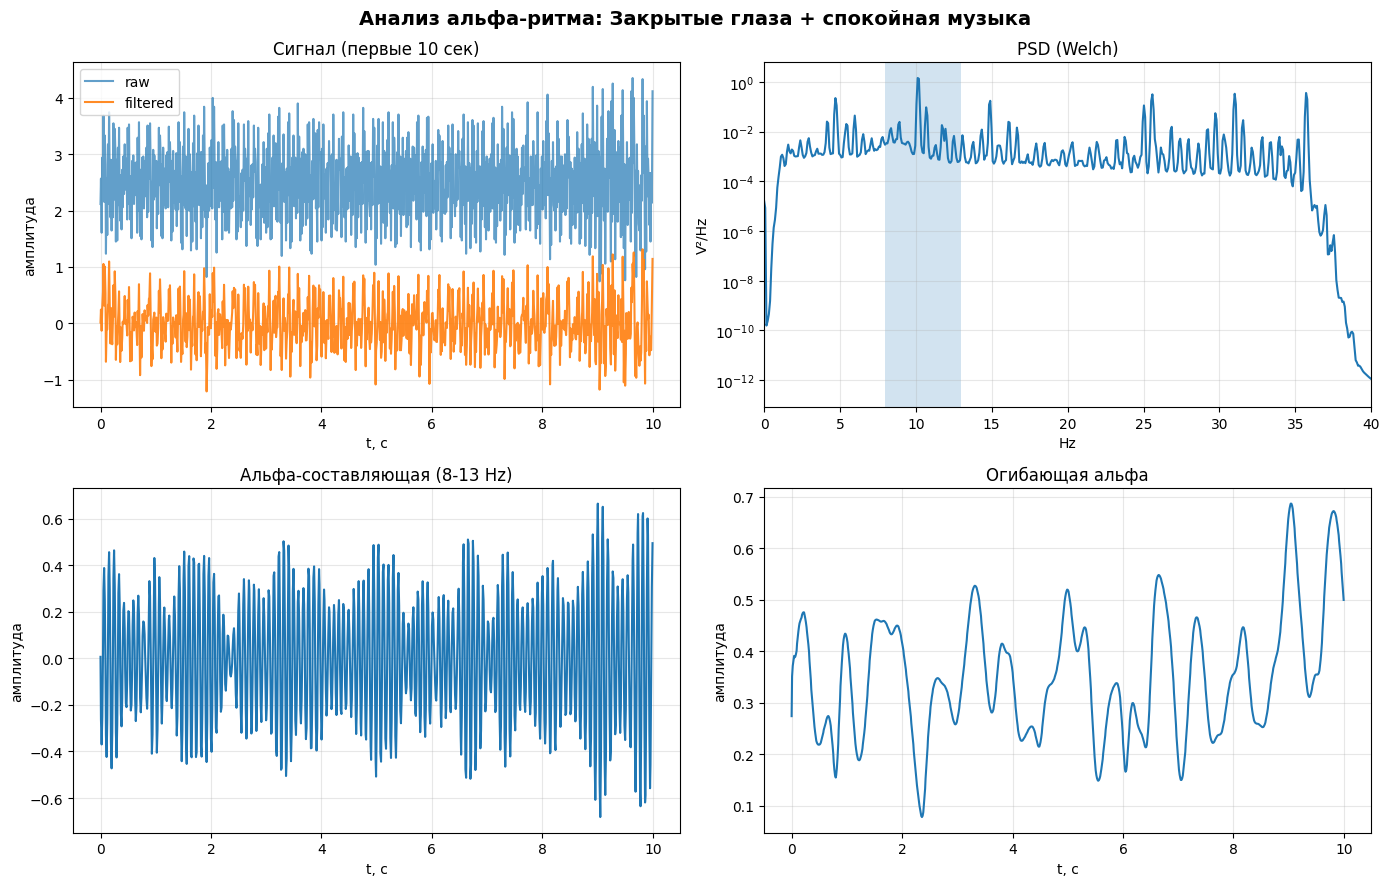

Закрытые глаза + спокойная музыка: alpha=0.266723, rel=0.4903


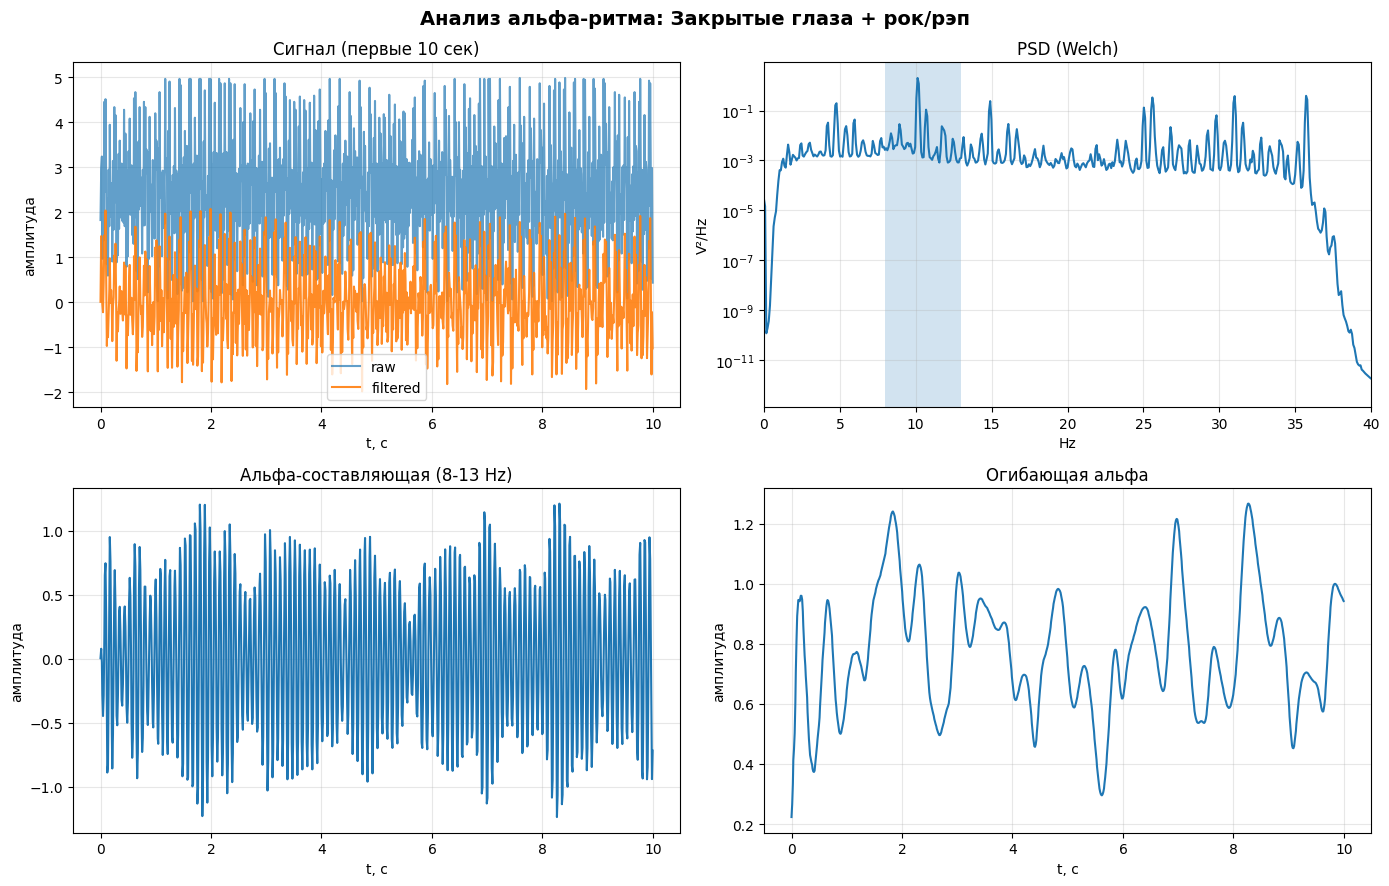

Закрытые глаза + рок/рэп: alpha=0.323036, rel=0.5020


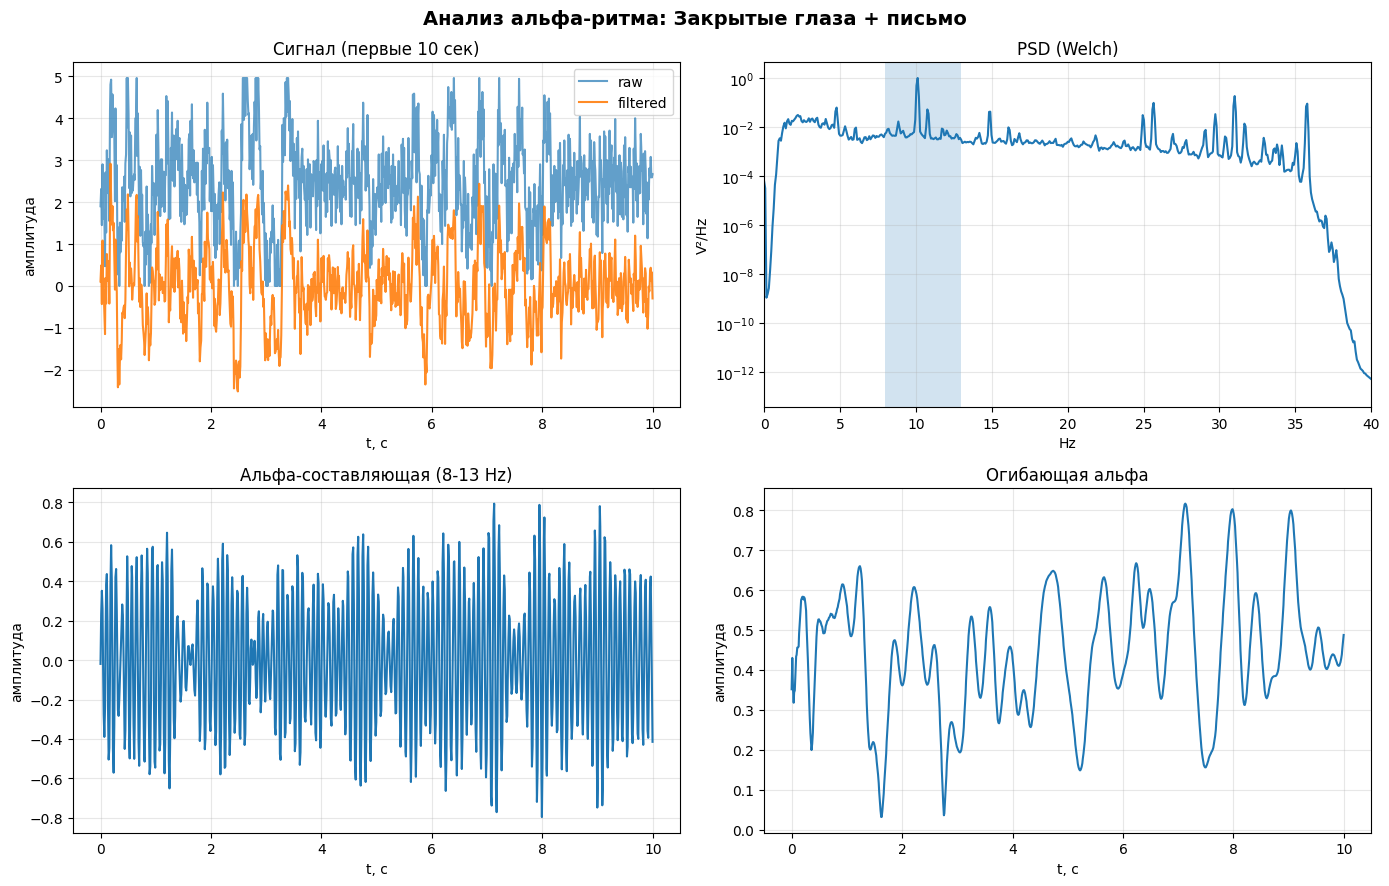

Закрытые глаза + письмо: alpha=0.171007, rel=0.4678


In [ ]:
# Графики по каждому условию
def plot_each_condition(res: Dict[str, Dict[str, Any]], first_seconds: int = 10) -> None:
    for name, d in res.items():
        t = d["t"]
        m = t <= first_seconds

        fig, ax = plt.subplots(2, 2, figsize=(14, 9))
        fig.suptitle(f"Анализ альфа-ритма: {name}", fontsize=14, fontweight="bold")

        # raw vs filtered
        ax[0, 0].plot(t[m], d["raw"][m], label="raw", alpha=0.7)
        ax[0, 0].plot(t[m], d["filt"][m], label="filtered", alpha=0.9)
        ax[0, 0].set_title(f"Сигнал (первые {first_seconds} сек)")
        ax[0, 0].set_xlabel("t, c")
        ax[0, 0].set_ylabel("амплитуда")
        ax[0, 0].grid(True, alpha=0.3)
        ax[0, 0].legend()

        # PSD
        ax[0, 1].semilogy(d["freqs"], d["psd"])
        ax[0, 1].axvspan(8, 13, alpha=0.2)
        ax[0, 1].set_xlim(0, 40)
        ax[0, 1].set_title("PSD (Welch)")
        ax[0, 1].set_xlabel("Hz")
        ax[0, 1].set_ylabel("V²/Hz")
        ax[0, 1].grid(True, alpha=0.3)

        # alpha component
        ax[1, 0].plot(t[m], d["alpha_sig"][m])
        ax[1, 0].set_title("Альфа-составляющая (8-13 Hz)")
        ax[1, 0].set_xlabel("t, c")
        ax[1, 0].set_ylabel("амплитуда")
        ax[1, 0].grid(True, alpha=0.3)

        # envelope
        ax[1, 1].plot(t[m], d["alpha_env"][m])
        ax[1, 1].set_title("Огибающая альфа")
        ax[1, 1].set_xlabel("t, c")
        ax[1, 1].set_ylabel("амплитуда")
        ax[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"{name}: alpha={d['alpha_power']:.6g}, rel={d['alpha_rel']:.4f}")

if results:
    plot_each_condition(results)


## Сравнение спектров (FFT) между условиями

Дополнительно строим один общий график амплитудных спектров, чтобы увидеть различия в спектре между условиями


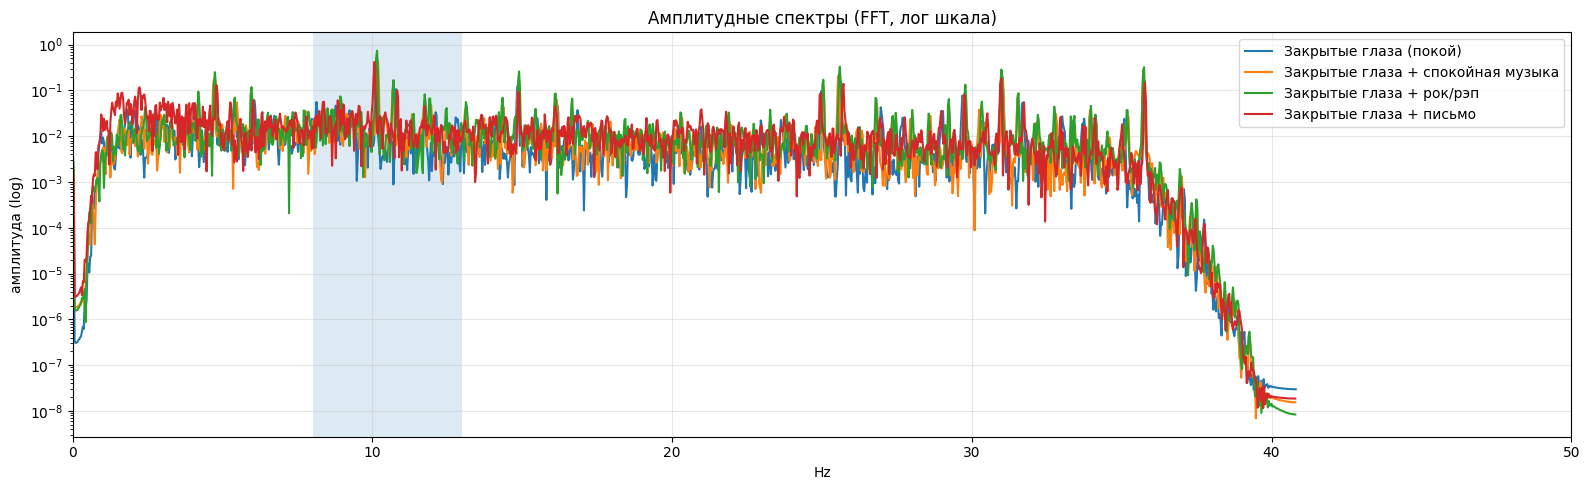

In [ ]:
# FFT сравнение
def fft_amplitude(x: np.ndarray, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    n = len(x)

    w = np.hanning(n)
    X = np.fft.rfft((x - x.mean()) * w)
    f = np.fft.rfftfreq(n, d=1 / fs)

    amp = np.abs(X) / (np.sum(w) / 2)
    return f, amp

def compare_fft_spectra(
    res: Dict[str, Dict[str, Any]],
    first_seconds: int = 30,
    fmax: int = 50
) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(16, 5))

    for name, d in res.items():
        t = d["t"]
        m = t <= first_seconds

        f, amp = fft_amplitude(d["filt"][m], d["fs"])
        mm = f <= fmax
        ax.semilogy(f[mm], amp[mm], label=name)

    ax.axvspan(8, 13, alpha=0.15)
    ax.set_xlim(0, fmax)
    ax.set_xlabel("Hz")
    ax.set_ylabel("амплитуда (log)")
    ax.set_title("Амплитудные спектры (FFT, лог шкала)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

if results:
    compare_fft_spectra(results)


## Таблица результатов и общий график


,Состояние,Отн. альфа
0,Закрытые глаза (покой),0.5352
1,Закрытые глаза + рок/рэп,0.5020
2,Закрытые глаза + спокойная музыка,0.4903
3,Закрытые глаза + письмо,0.4678


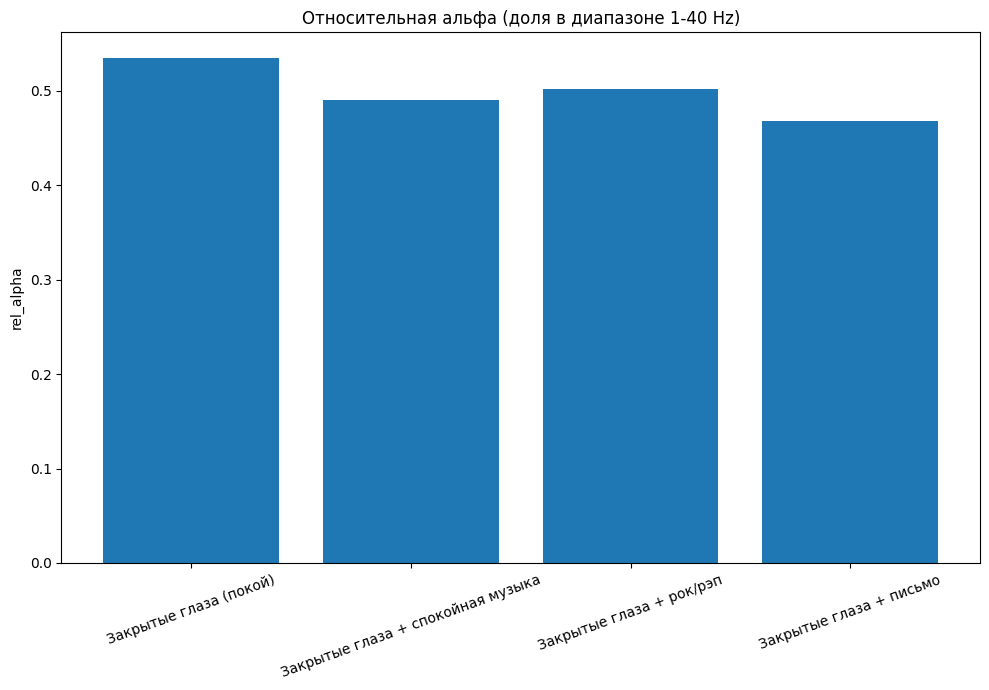

Максимальная относительная альфа: 'Закрытые глаза (покой)'
Минимальная относительная альфа: 'Закрытые глаза + письмо'


In [ ]:
# Таблица и итоговый график
def summary_table(res: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for name, d in res.items():
        rows.append({
            "Состояние": name,
            "Отн. альфа": d["alpha_rel"],\
        })

    df = (
        pd.DataFrame(rows)
        .sort_values("Отн. альфа", ascending=False)
        .reset_index(drop=True)
    )
    return df

def plot_summary(res: Dict[str, Dict[str, Any]]) -> None:
    labels = list(res.keys())
    rel = [res[k]["alpha_rel"] for k in labels]

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.bar(labels, rel)
    ax.set_title("Относительная альфа (доля в диапазоне 1-40 Hz)")
    ax.set_ylabel("rel_alpha")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

if results:
    df = summary_table(results)
    display(df.style.format({
        "Отн. альфа": "{:.4f}",
    }))

    plot_summary(results)

    best = df.iloc[0]["Состояние"]
    worst = df.iloc[-1]["Состояние"]
    print(f"Максимальная относительная альфа: '{best}'")
    print(f"Минимальная относительная альфа: '{worst}'")


## Общие выводы по результатам

Ранжирование по убыванию:

1) Закрытые глаза (покой) - 0.5352  
2) Закрытые глаза + рок/рэп - 0.5020  
3) Закрытые глаза + спокойная музыка - 0.4903  
4) Закрытые глаза + письмо - 0.4678

На PSD у всех условий заметен пик в зоне 8-13 Hz, то есть альфа-компонента присутствует

Покой с закрытыми глазами дает самую высокую альфу, что совпадает с общим правилом: когда человек расслаблен и нет активной работы/внимания, альфа обычно сильнее. Письмо наоборот дало самую низкую альфу. Это тоже ожидаемо: любая умственная нагрузка обычно "съедает" альфу (она становится слабее), потому что мозг активнее обрабатывает информацию. У бодрой музыки альфа выше, чем у спокойной музыки, что может быть индивидуальным эффектом:
- спокойная музыка могла больше цеплять внимание (хотелось слушать/анализировать), и альфа чуть просела;
- рок/рэп мог быть "фоном" (меньше внимания) - альфа просела меньше

### Итог
- Главный вывод: максимальная альфа - в покое, минимальная - при задании (письмо). Это хорошо сходится с теорией про рост альфы в расслаблении и снижение при умственной работе/внимании.
- Музыкальные условия дали слабое снижение относительно покоя и небольшую разницу между жанрами - это укладывается в то, что эффект музыки бывает нестабильным и зависит от человека и контекста.
